<a href="https://colab.research.google.com/github/Janhvesh-Patil/RiskLens-AI/blob/main/backend/TransactionFraudDetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the Dataset from Kaggle - https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [78]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f"{path}/creditcard.csv")

In [80]:
import os, joblib
from google.colab import drive
drive.mount('/content/drive')

MODEL_DIR = '/content/drive/MyDrive/RiskLensAI/models'
os.makedirs(MODEL_DIR, exist_ok=True)

def load_or_train(pipeline, filename, X_train, y_train):
    path = f"{MODEL_DIR}/{filename}"
    if os.path.exists(path):
        print(f"Loading cached: {filename}")
        return joblib.load(path)
    print(f"Training: {filename}")
    pipeline.fit(X_train, y_train)
    joblib.dump(pipeline, path)
    return pipeline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Understanding Data

In [81]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Here Class 0 = "Not fraud" and 1 = "fraud".
### Features V1, V2, … V28 are the principal components obtained with PCA.
### Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset.
### The feature 'Amount' is the transaction Amount

In [82]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


### All numeric values, that's great

In [83]:
df.shape

(284807, 31)

In [84]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [85]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### No Null values, so no data cleaning required in this place

## Visualizing the Data

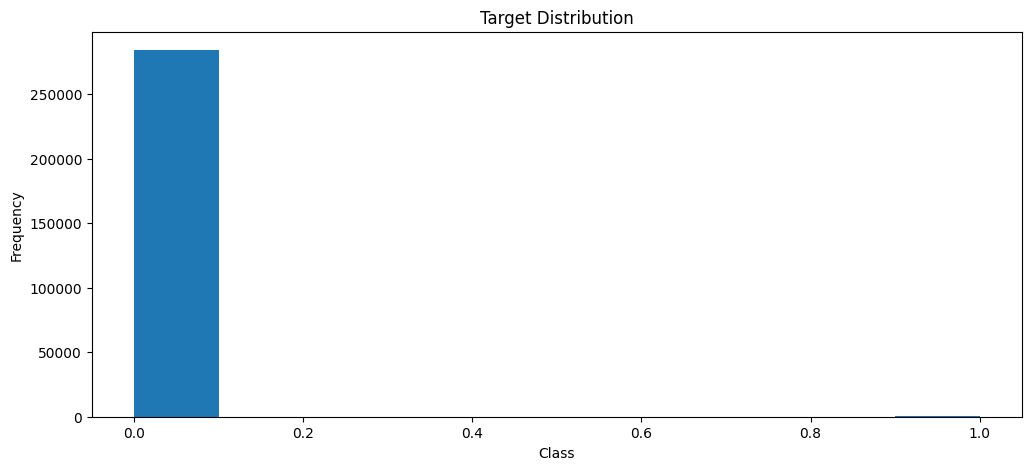

In [86]:
# Target Distribution

targetColumn = df["Class"]

plt.figure(figsize = (12, 5))
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.hist(targetColumn)
plt.show()

### This is massive class imbalance

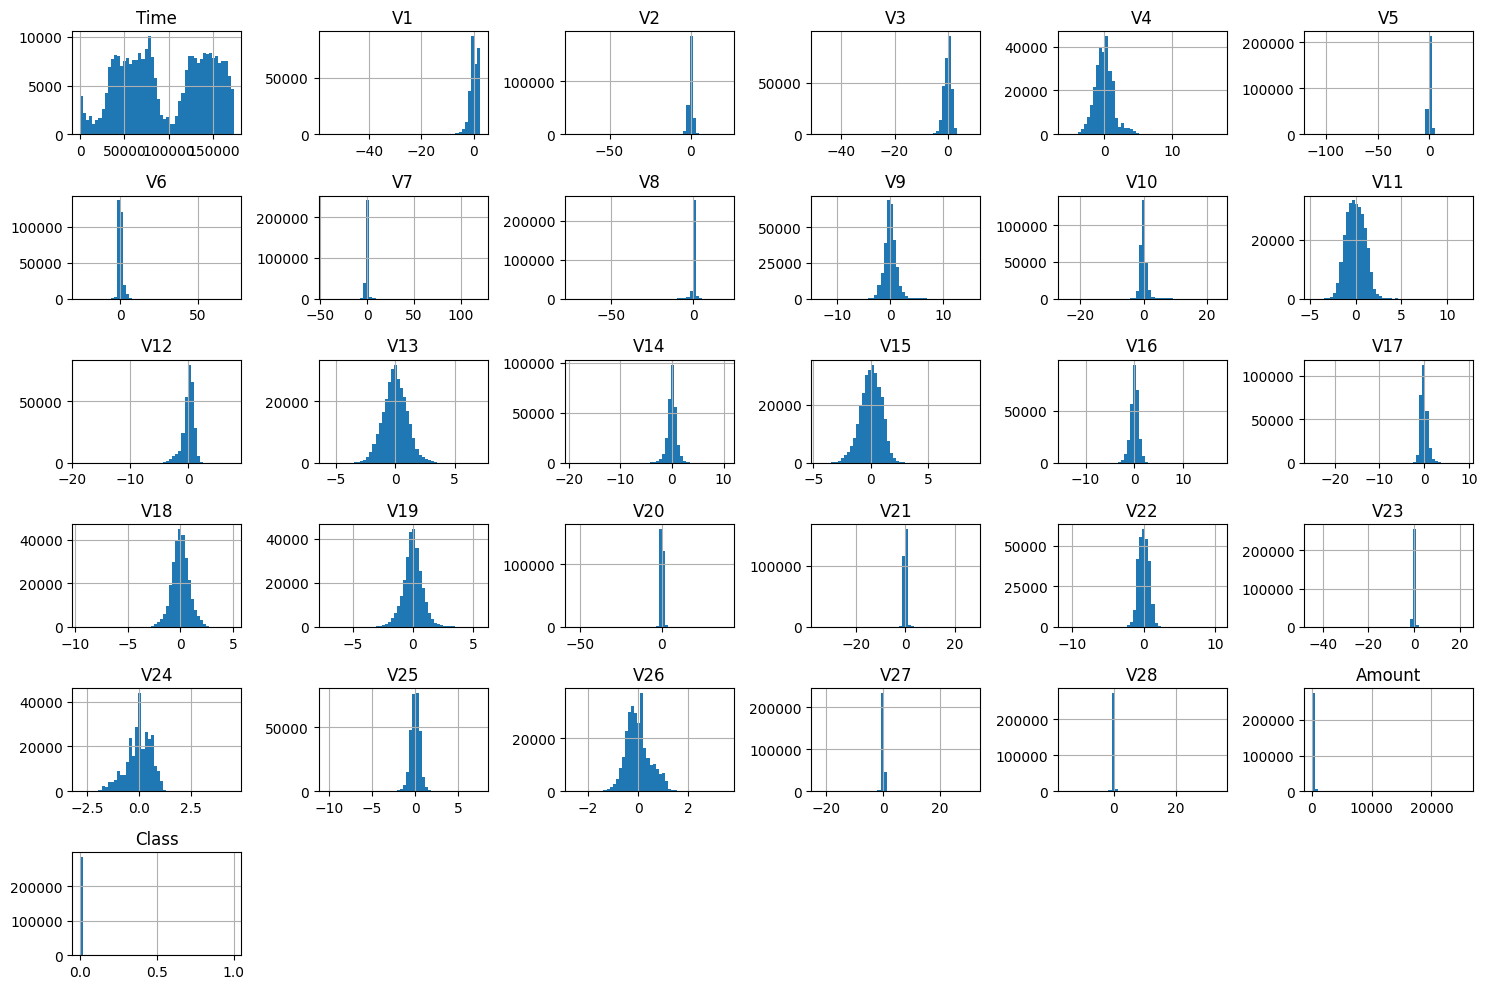

In [87]:
# All the columns distribution

df.hist(figsize = (15, 10), bins = 50)
plt.tight_layout()
plt.show()

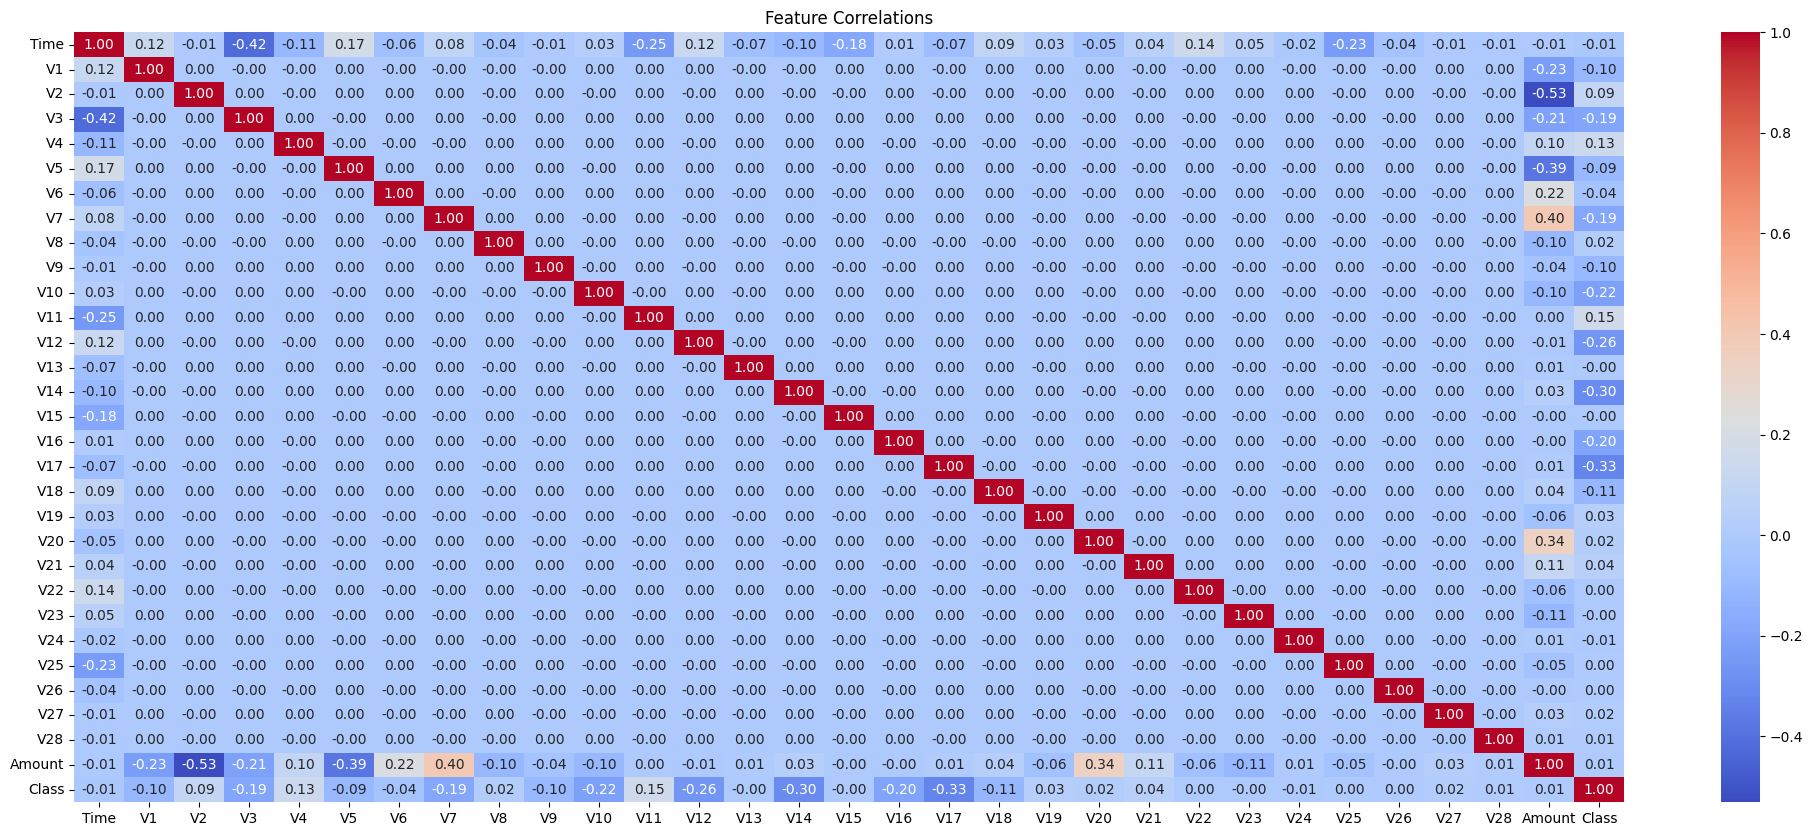

In [88]:
# Finding correlations using heatmap
features = df.columns.tolist()

plt.figure(figsize=(25,10))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

### No highlighting correlations

In [89]:
correlations = df.corr()["Class"].drop("Class")
topFeatures = correlations.abs().nlargest(10).index.tolist()

topFeatures

['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

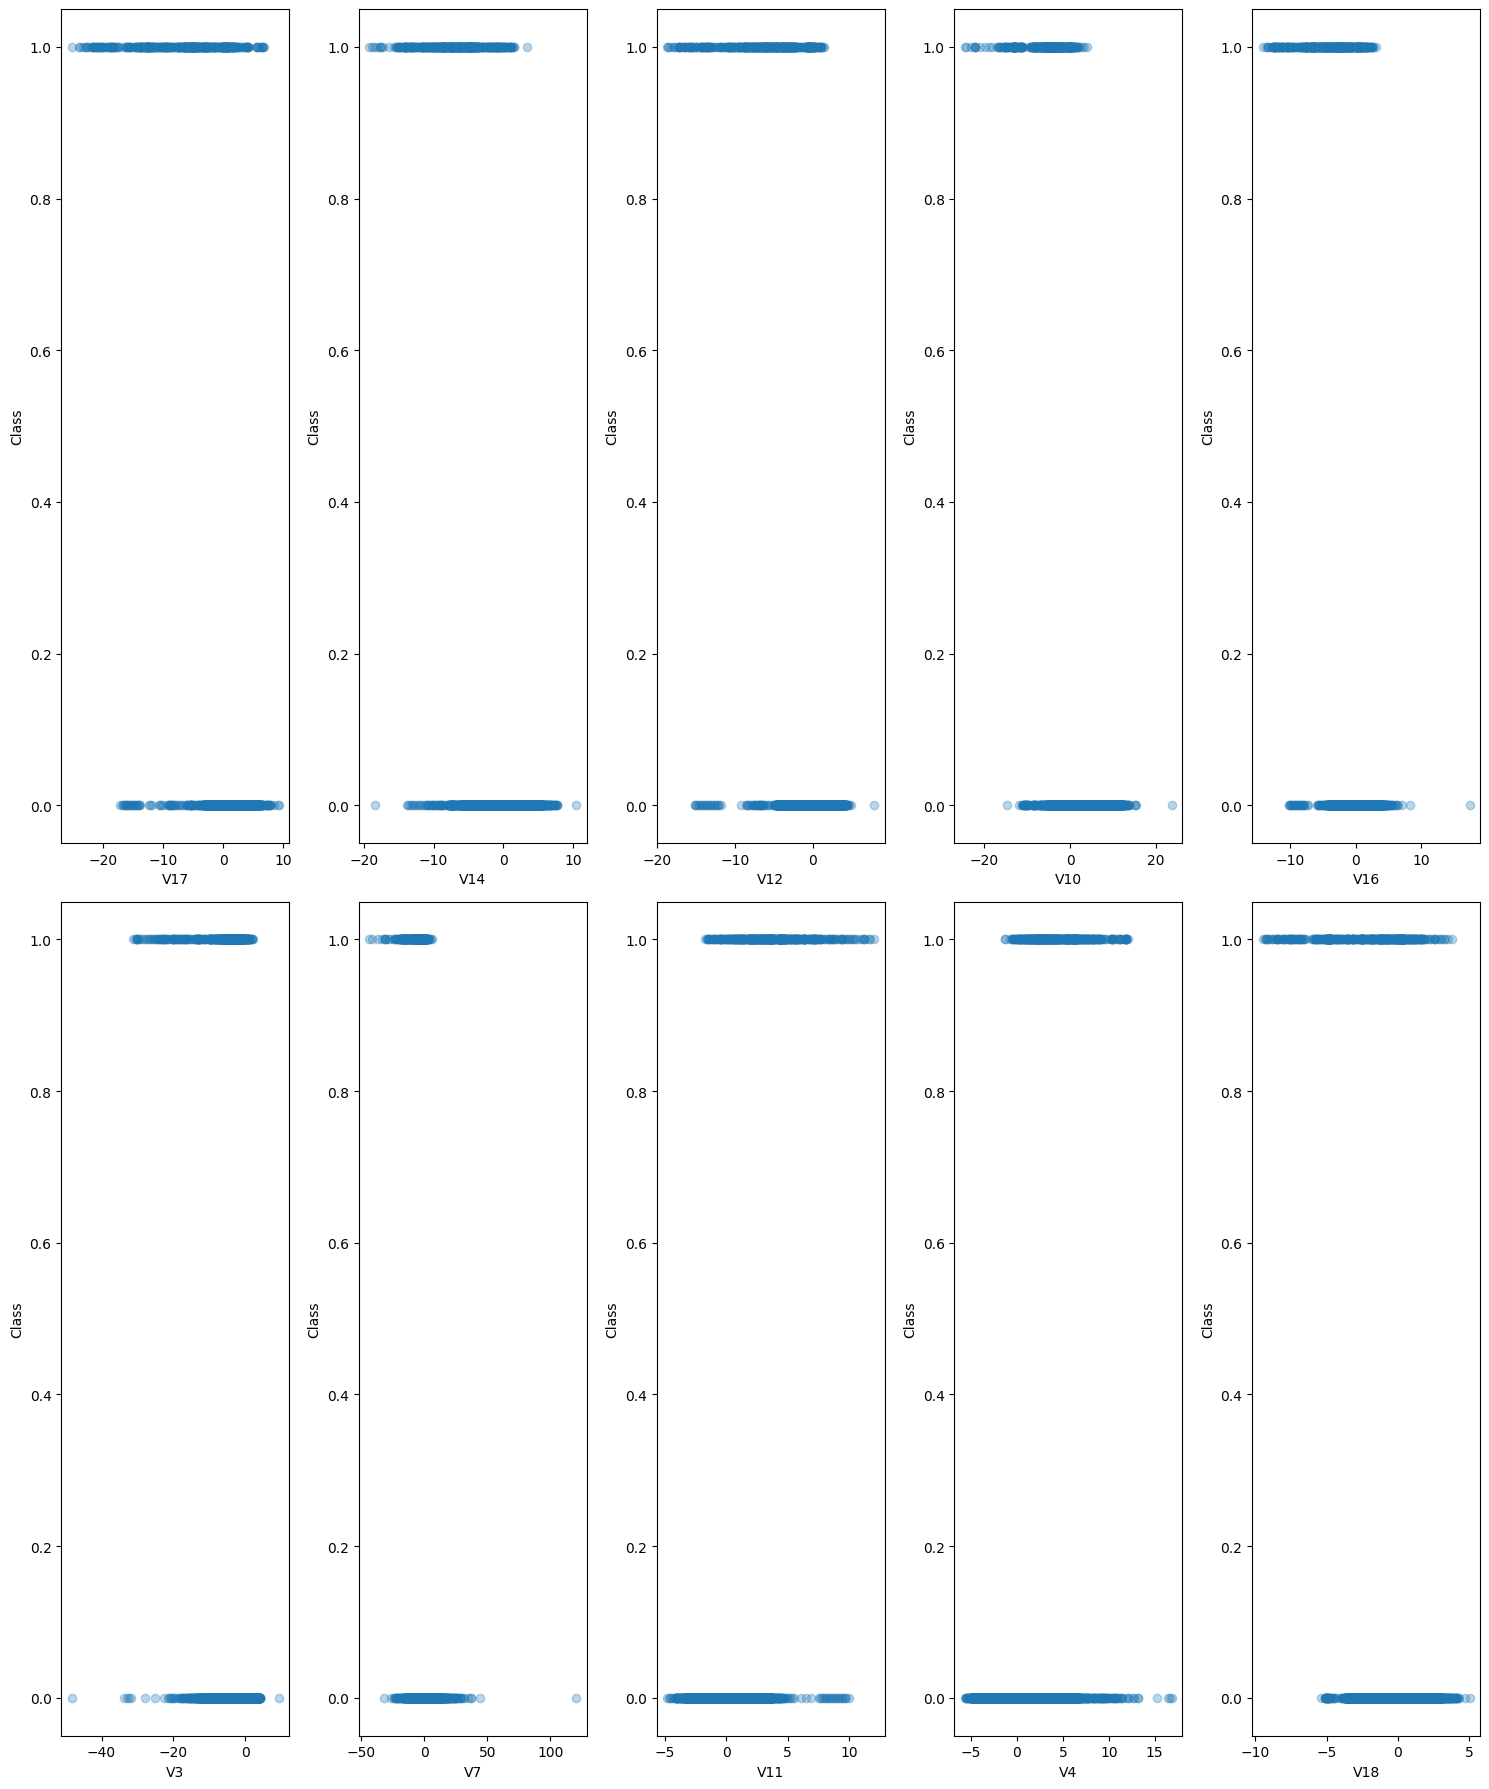

In [90]:
# Scatterplots of top features

fig, axes = plt.subplots(2, 5, figsize=(15,18))
for i, feature in enumerate(topFeatures):
    ax = axes[i//5, i%5]
    ax.scatter(df[feature], df["Class"], alpha=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

### No much helpful.

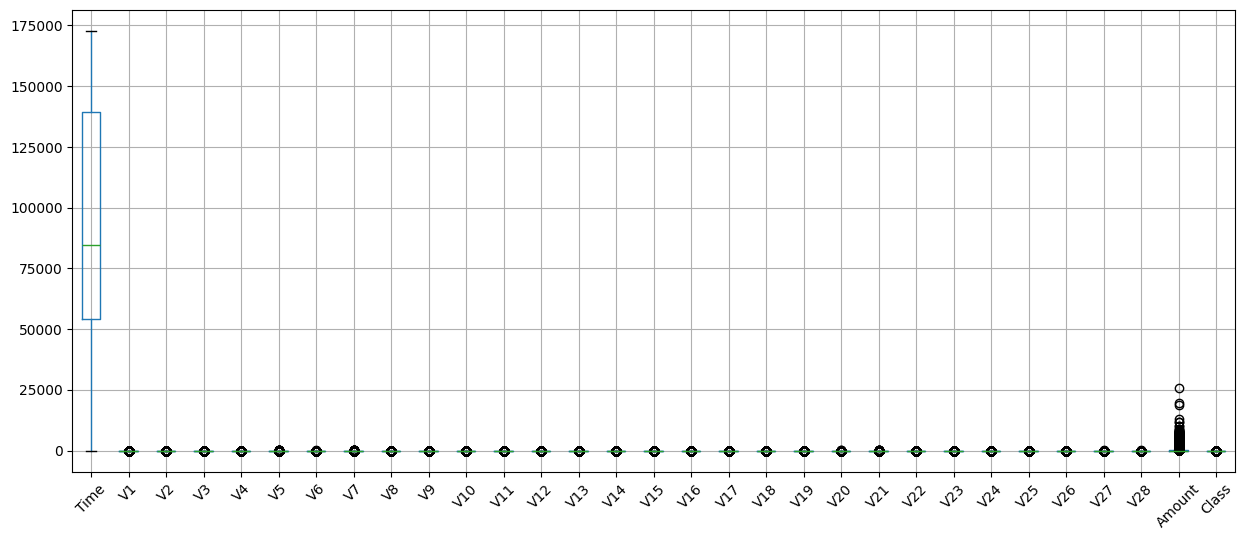

In [91]:
# Boxplots for outlier detection
plt.figure(figsize=(15,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()


### A lot of outliers in Amount feature.

In [92]:
print(f"Fraud rate: {df["Class"].mean():.2%}")
print(f"Class distribution:\n{df["Class"].value_counts()}")

Fraud rate: 0.17%
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


# Data Cleaning

## Need to handle the outliers

In [93]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")
print(f"Lower bound = {lower}")
print(f"Upper bound = {upper}")

outliers = df[
    (df['Amount'] < lower) |
    (df['Amount'] > upper)
]

print(f"Number of outliers = {len(outliers)}")
print(f"Fraud among outliers = {outliers['Class'].sum()}")

Q1 = 5.6
Q3 = 77.16499999999999
IQR = 71.565
Lower bound = -101.7475
Upper bound = 184.5125
Number of outliers = 31904
Fraud among outliers = 91


### Amount is heavily skewed therefore we need to compress it without loosing the values

In [94]:
# Creating a custom transformer to handle this
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class AmountTransformer(BaseEstimator, TransformerMixin):
  def __init__(self):
    return None

  def fit(self, X, y = None):
    return self

  def transform(self, X):
    X = X.copy()
    X["Amount"] = X["Amount"].apply(np.log1p)
    return X

In [95]:
numericPipeLine = Pipeline([
    ("scaler", StandardScaler())
])

In [96]:
amountPipeline = Pipeline([
    ("log", AmountTransformer()),
    ("scale", StandardScaler())
])

# Data Preprocessing

In [97]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ("num", numericPipeLine, [c for c in df.columns if c not in ("Amount", "Class")]),
    ("amount", amountPipeline, ["Amount"])
])

In [98]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 1081


In [99]:
print(df[df.duplicated()]['Class'].sum())

19


### Removing these duplicates and reseting the index to not cause data leakeage during train/test split

In [100]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# Training the model

In [101]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis = 1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 42)

In [102]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)


def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a classification model using:
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - Confusion Matrix
    - Classification Report
    - Precision-Recall vs Threshold plot
    """

    # Predictions
    predictions = model.predict(X_test)

    # Probability predictions
    probability_predictions = model.predict_proba(X_test)[:, 1]

    # Basic metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    average_precision = average_precision_score(
        y_test,
        probability_predictions
    )

    print(f"========== {model_name} ==========")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"Average Precision: {average_precision:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, predictions, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    # Precision-Recall curve across thresholds
    precision_values, recall_values, thresholds = precision_recall_curve(
        y_test,
        probability_predictions
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds,
        precision_values[:-1],
        label="Precision"
    )

    plt.plot(
        thresholds,
        recall_values[:-1],
        label="Recall"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Value")
    plt.title(f"Precision / Recall vs Threshold - {model_name}")
    plt.legend()
    plt.show()

    return {
        "model": model_name,
        "predictions": predictions,
        "probabilities": probability_predictions,
        "precision": precision_values,
        "recall": recall_values,
        "thresholds": thresholds,
        "accuracy": accuracy,
        "precision_score": precision,
        "recall_score": recall,
        "f1_score": f1,
        "average_precision": average_precision
    }

In [103]:
from sklearn.linear_model import LogisticRegression

fullPipeline_LR = Pipeline([
    ("preprocessor", preprocessing),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

Loading cached: lr.pkl
========== Logistic Regression ==========
Accuracy : 0.9749
Precision: 0.0554
Recall   : 0.8737
F1       : 0.1042
Average Precision: 0.6770

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746



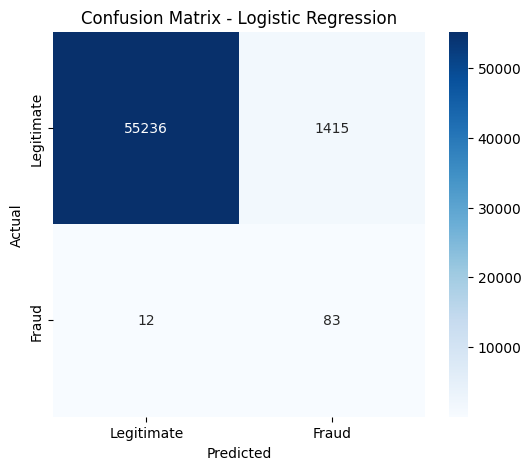

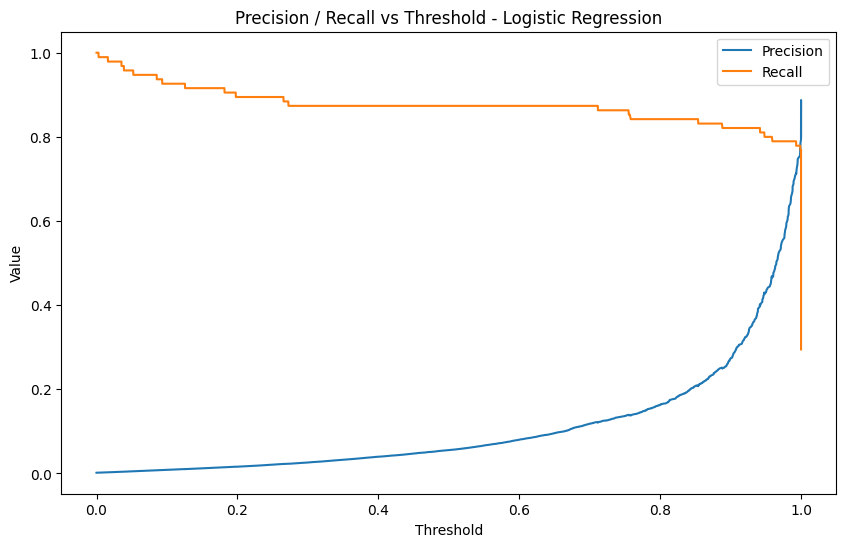

In [104]:
fullPipeline_LR = load_or_train(fullPipeline_LR, "lr.pkl", X_train, y_train)
lr_results = evaluate_model(
    fullPipeline_LR,
    X_test,
    y_test,
    "Logistic Regression"
)

### Confusion Matrix

### Precision score of 0.055 -> Of all transactions flagged as fraud, only ~5.5% were truly fraudulent.

### Recall score of 0.874 -> Of all actual fraudulent transactions, the model successfully caught ~87.4%.

### F1 score of 0.104 -> is the balance between precision and recall which is low due to poor precision

### The predict() uses a threshold of 0.5. This led to the huge difference in recall and low precision.

## How confident does the model need to be before we call something fraud?

At different confidence cutoffs, we get a different trade-off:
- Low cutoff = catch more fraud, but wrongly flag more innocent transactions
- High cutoff = fewer wrong flags, but miss more real fraud

This graph shows that trade-off at every possible cutoff, so we can pick
one on purpose instead of using the default 0.5.

### Figuring out the FP-cost and FN-Cost

In [105]:
def calculate_threshold_cost(
    probabilities,
    X_test,
    y_test,
    thresholds,
    false_positive_cost=50
):
    """
    Calculate business cost for every probability threshold.

    FN cost  = actual transaction amount lost
    FP cost  = fixed cost per false alarm
    """

    total_cost = []

    for threshold in thresholds:

        y_pred = (probabilities >= threshold).astype(int)

        fn_mask = (y_test == 1) & (y_pred == 0)
        fp_mask = (y_test == 0) & (y_pred == 1)

        fn_cost = X_test.loc[fn_mask, "Amount"].sum()
        fp_cost = false_positive_cost * fp_mask.sum()

        total_cost.append(fn_cost + fp_cost)

    return np.array(total_cost)

In [106]:
lr_costs = calculate_threshold_cost(
    lr_results["probabilities"],
    X_test,
    y_test,
    lr_results["thresholds"]
)

In [107]:
def plot_threshold_cost(thresholds, costs, model_name, xlim=None):

    plt.figure(figsize=(12, 6))

    plt.plot(thresholds, costs)

    if xlim:
        plt.xlim(*xlim)

    plt.xlabel("Threshold")
    plt.ylabel("Total Cost")
    plt.title(f"Threshold vs Total Cost - {model_name}")

    plt.show()

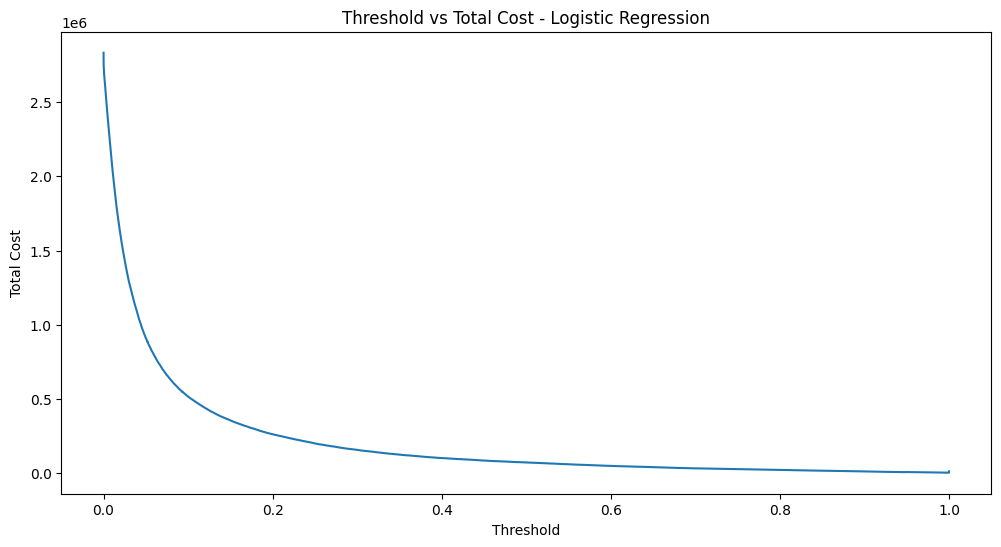

In [108]:
plot_threshold_cost(
    lr_results["thresholds"],
    lr_costs,
    "Logistic Regression"
)

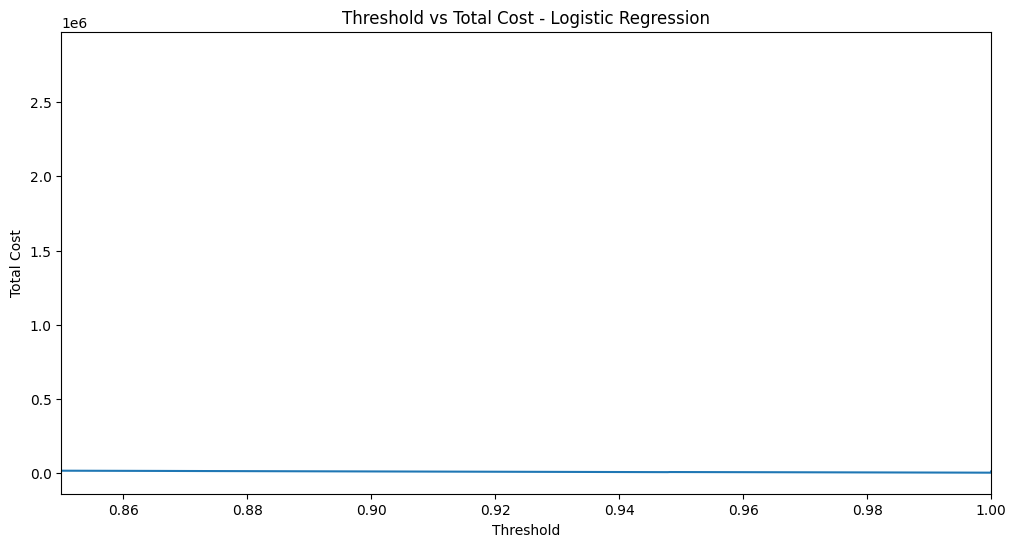

In [109]:
# plotting thresholds vs total_cost

plot_threshold_cost(
    lr_results["thresholds"],
    lr_costs,
    "Logistic Regression",
    xlim=(0.85, 1.0)
)

In [110]:
print(
    lr_results["thresholds"][np.argmin(lr_costs)]
)

0.9999999591558791


## Is the "best" cutoff actually trustworthy?

The lowest-cost cutoff came out to ~0.9999999, which basically means
"only flag something if we're almost completely certain." Before trusting
that number, we need to check whether it's backed by real data or whether
it's just a fluke — very few transactions actually get scored near 1.0.

In [111]:
X_test.loc[y_test==1, 'Amount'].describe() # sanity check to see using a ₹ 50 cost for false positive is reliable

,Amount
count,95.000000
mean,155.434842
std,311.293511
min,0.000000
25%,1.000000
50%,12.310000
75%,109.615000
max,1809.680000


In [112]:
print(
    (lr_results["probabilities"] >= 0.9999999591558791).sum()
)

80


In [113]:
# Only look at a realistic range of cutoffs — avoids the unreliable
# extreme-confidence tail where very few transactions actually land.
mask = (
    (lr_results["thresholds"] >= 0.5) &
    (lr_results["thresholds"] <= 0.95)
)

narrow_thresholds = lr_results["thresholds"][mask]
narrow_costs = np.array(lr_costs)[mask]

best_threshold = narrow_thresholds[
    np.argmin(narrow_costs)
]

print("Best threshold in realistic range:", best_threshold)

Best threshold in realistic range: 0.9478125526637202


In [114]:
print(
    (lr_results["probabilities"] >= best_threshold).sum()
)

179


### The the more we decrease the windown the more we see the threshold lies on the upper bound always. So we try to find a threshold we maintains atleast 75% recall

In [115]:
def choose_threshold(
    thresholds,
    recall_values,
    costs,
    recall_floor=0.75,
    threshold_cap=0.95
):
    """
    Select the lowest-cost threshold that:
    - achieves at least the required recall
    - does not exceed the threshold cap
    """

    recall_values = recall_values[:len(thresholds)]

    valid = (
        (recall_values >= recall_floor) &
        (thresholds <= threshold_cap)
    )

    if not valid.any():
        raise ValueError(
            "No threshold satisfies the recall requirement."
        )

    valid_thresholds = thresholds[valid]
    valid_costs = costs[valid]

    best_index = np.argmin(valid_costs)

    return (
        valid_thresholds[best_index],
        valid_costs[best_index],
        recall_values[valid][best_index]
    )

We already showed cost keeps falling with threshold in this range — no real
minimum to find by cost alone. Instead: pick the highest threshold that still
catches at least 75% of fraud, and report its cost. This is a deliberate
business constraint, not a raw cost-minimum.

In [116]:
lr_threshold, lr_cost, lr_recall = choose_threshold(
    lr_results["thresholds"],
    lr_results["recall"],
    lr_costs,
    recall_floor=0.75,
    threshold_cap=0.95
)

print("LR chosen threshold:", lr_threshold)
print("LR recall:", lr_recall)
print("LR total cost:", lr_cost)

LR chosen threshold: 0.9478125526637202
LR recall: 0.8105263157894737
LR total cost: 8158.13


# Confusion Matrix on the chosen threshold

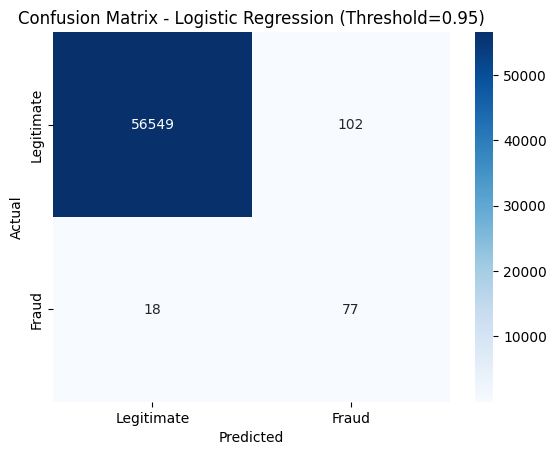

In [117]:
y_pred_on_chosen_threshold = (
    lr_results["probabilities"] >= lr_threshold
).astype(int)

cm = confusion_matrix(y_test, y_pred_on_chosen_threshold)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Confusion Matrix - Logistic Regression (Threshold={lr_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [118]:
lr_precision = precision_score(
    y_test,
    y_pred_on_chosen_threshold
)

lr_recall = recall_score(
    y_test,
    y_pred_on_chosen_threshold
)

lr_accuracy = accuracy_score(
    y_test,
    y_pred_on_chosen_threshold
)

lr_f1 = f1_score(
    y_test,
    y_pred_on_chosen_threshold
)

print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1 Score: {lr_f1:.4f}")

Precision: 0.4302
Recall: 0.8105
Accuracy: 0.9979
F1 Score: 0.5620


### Final threshold: 0.9478, chosen as the cheapest option that still catches ≥75% of fraud.

### At this threshold:
precision 0.4302
recall 0.81
F1 0.5620
total cost 8158.13.

Assumptions: ₹50 per false positive (based on typical manual-review cost ranges), real transaction amount per missed fraud.

# Trying Naive bayes

In [119]:
from sklearn.naive_bayes import GaussianNB

fullPipeline_NB = Pipeline([
    ("preprocessor", preprocessing),
    ("model", GaussianNB())
])

Loading cached: nb.pkl
========== Naive Bayes ==========
Accuracy : 0.9774
Precision: 0.0575
Recall   : 0.8105
F1       : 0.1073
Average Precision: 0.0764

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.81      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.89      0.55     56746
weighted avg       1.00      0.98      0.99     56746



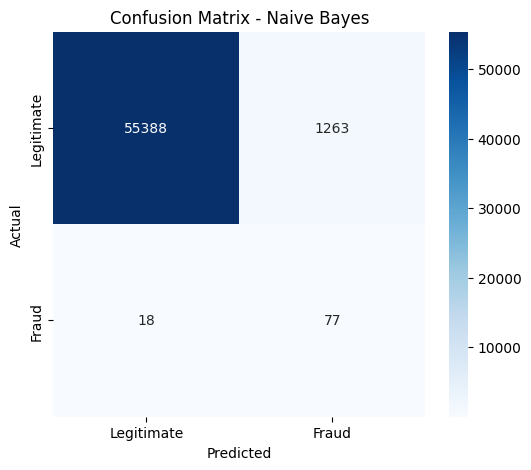

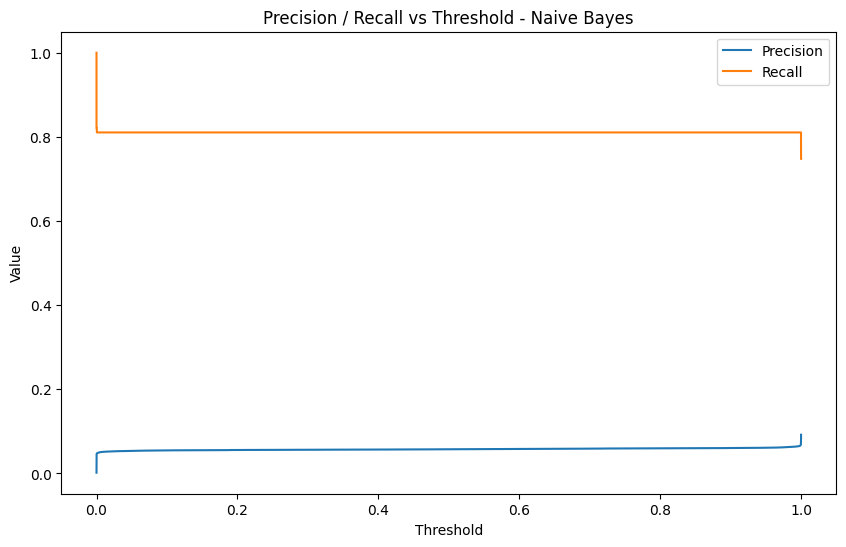

In [120]:
fullPipeline_NB = load_or_train(fullPipeline_NB, "nb.pkl", X_train, y_train)

"""
LR metrics ->
Accuracy Score:  0.9748528530645332
Precision Score:  0.05540720961281709
Recall Score:  0.8736842105263158
F1 Score:  0.10420590081607031
"""

nb_results = evaluate_model(
    fullPipeline_NB,
    X_test,
    y_test,
    "Naive Bayes"
)

NB's probabilities cluster near 0/1 (a known effect of multiplying many
near-independent feature likelihoods), so the precision-recall trade-off is
mostly flat across the middle of the threshold range — less room for the
kind of cost-based threshold tuning we did for Logistic Regression.

# Now trying Random Forest Classifier

In [121]:
from sklearn.ensemble import RandomForestClassifier

fullPipeline_RF = Pipeline([
    ("preprocessor", preprocessing),
    ("model", RandomForestClassifier(class_weight = "balanced", random_state = 42, n_jobs = -1))
])

Loading cached: rf_untuned.pkl
========== Random Forest ==========
Accuracy : 0.9995
Precision: 0.9710
Recall   : 0.7053
F1       : 0.8171
Average Precision: 0.7957

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



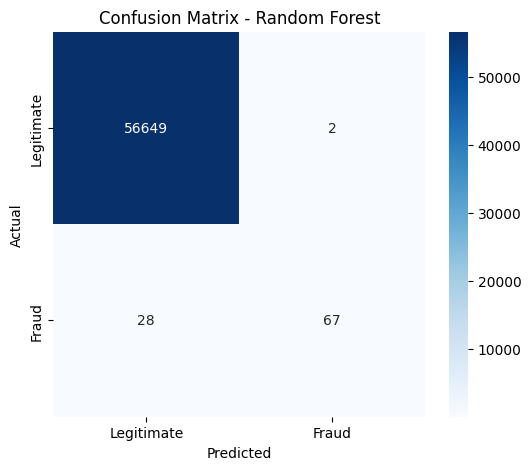

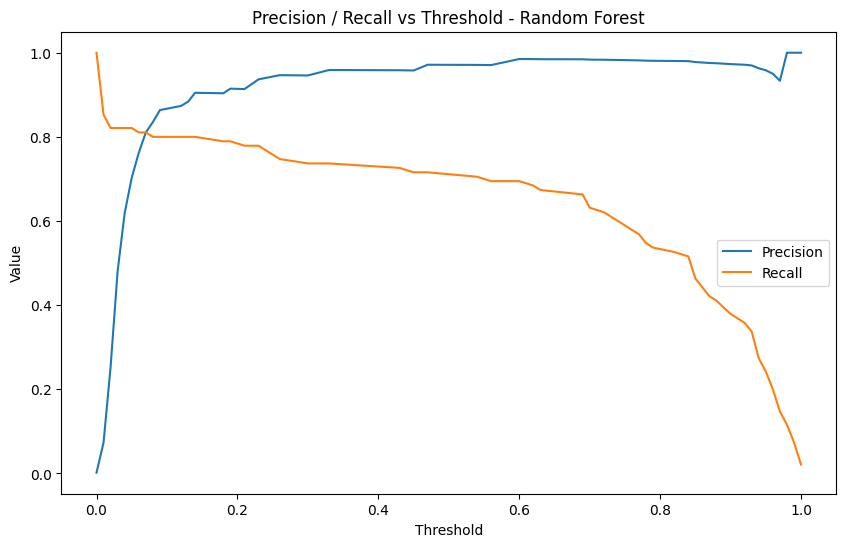

In [122]:
fullPipeline_RF = load_or_train(fullPipeline_RF, "rf_untuned.pkl", X_train, y_train)
"""
LR metrics ->
Accuracy Score:  0.9748528530645332
Precision Score:  0.05540720961281709
Recall Score:  0.8736842105263158
F1 Score:  0.10420590081607031
"""

rf_results = evaluate_model(
    fullPipeline_RF,
    X_test,
    y_test,
    "Random Forest"
)

Random forest has a great score in temrs of precision and recall, clearly much better than Logistic Regression. Therefore, we move to hypertuning it using the Grid Search

In [123]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

gridSearchPipeline = Pipeline([
    ("preprocessor", preprocessing),
    ("model", RandomForestClassifier(n_estimators = 50, random_state = 42))
])

In [124]:
param_dist = {
    "model__max_depth" : [8, 12, 16],
    "model__class_weight" : [None, "balanced", "balanced_subsample"],
    "model__min_samples_leaf" : [1, 2, 4],
}

cv_strategy = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

In [125]:
gridSearch = RandomizedSearchCV(
    estimator = gridSearchPipeline,
    param_distributions = param_dist,
    n_iter = 8,
    cv = cv_strategy,
    scoring = "average_precision",
    n_jobs = -1,
    verbose = 1,
    random_state = 42
)

# gridSearch.fit(X_train, y_train) <- previously

gs_path = f"{MODEL_DIR}/rf_tuned.pkl"   # newly <- added
if os.path.exists(gs_path):
    best_model = joblib.load(gs_path)
    print("Loaded cached tuned RF")
else:
    gridSearch.fit(X_train, y_train)
    best_model = gridSearch.best_estimator_
    joblib.dump(best_model, gs_path)

Loaded cached tuned RF


In [128]:
# print("Grid Search best params : ", gridSearch.best_params_)
# print("Grid Search best score : ", gridSearch.best_score_)

print("Selected model:")
print(best_model)

print("\nBest Random Forest parameters:")
print(best_model.named_steps["model"].get_params())

Selected model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27',
                                                   'V28']),
                                                 ('amount',
                                                  Pipeline(steps

========== Tuned Random Forest ==========
Accuracy : 0.9995
Precision: 0.9333
Recall   : 0.7368
F1       : 0.8235
Average Precision: 0.8127

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.74      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



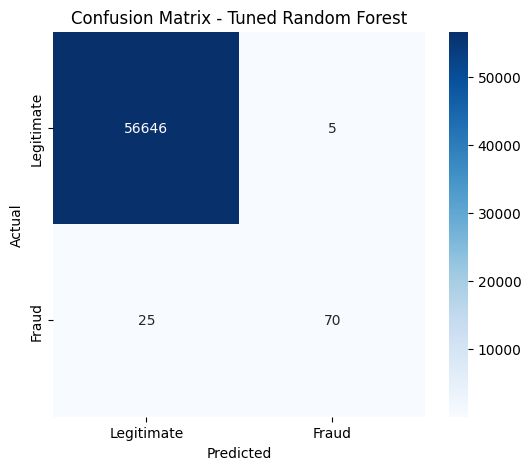

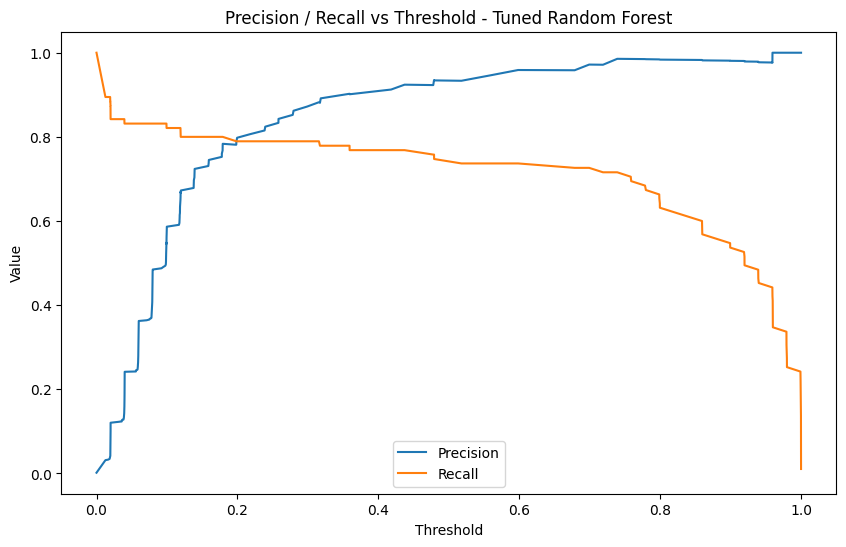

In [129]:
best_rf_results = evaluate_model(
    best_model,
    X_test,
    y_test,
    "Tuned Random Forest"
)

### Grid search initially underperformed the untuned baseline because runtime constraints required capping max_depth and reducing n_estimators during the search phase; the winning hyperparameters were then retrained with those constraints relaxed for the final model.

## Note: max_depth cap during grid search

Manually retrained RF with `max_depth=None` (unconstrained) and 150 trees,
keeping the grid search's other winning params (`min_samples_leaf=4`,
`class_weight='balanced'`). Result was numerically identical to the
grid-search-selected model — confirming `min_samples_leaf=4` was the
binding constraint on tree growth, not `max_depth`. The `max_depth` cap
imposed during grid search (needed to keep search runtime manageable)
did not cost us anything in this case.

## Running full evaluation like for LR

In [130]:
tuned_costs = calculate_threshold_cost(
    best_rf_results["probabilities"],
    X_test, y_test,
    best_rf_results["thresholds"]
)

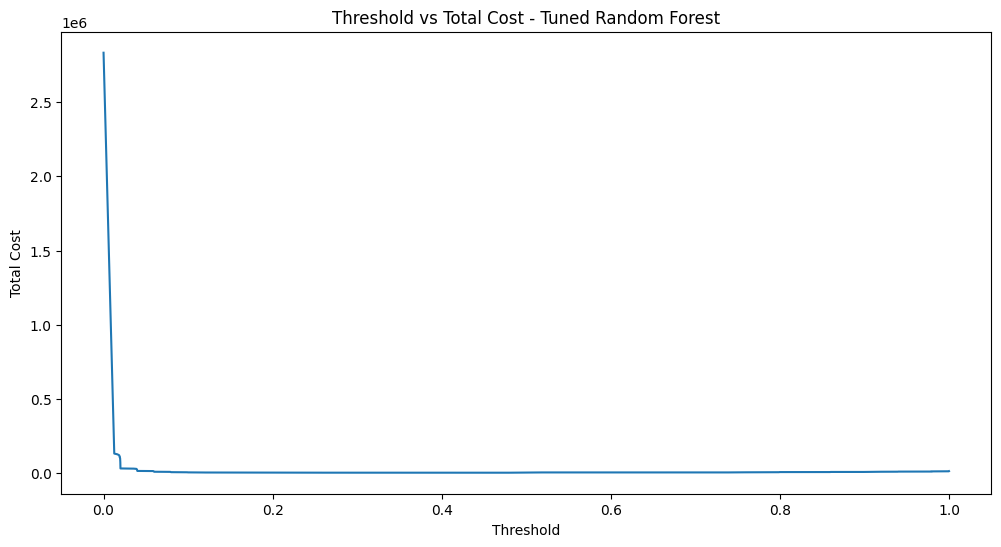

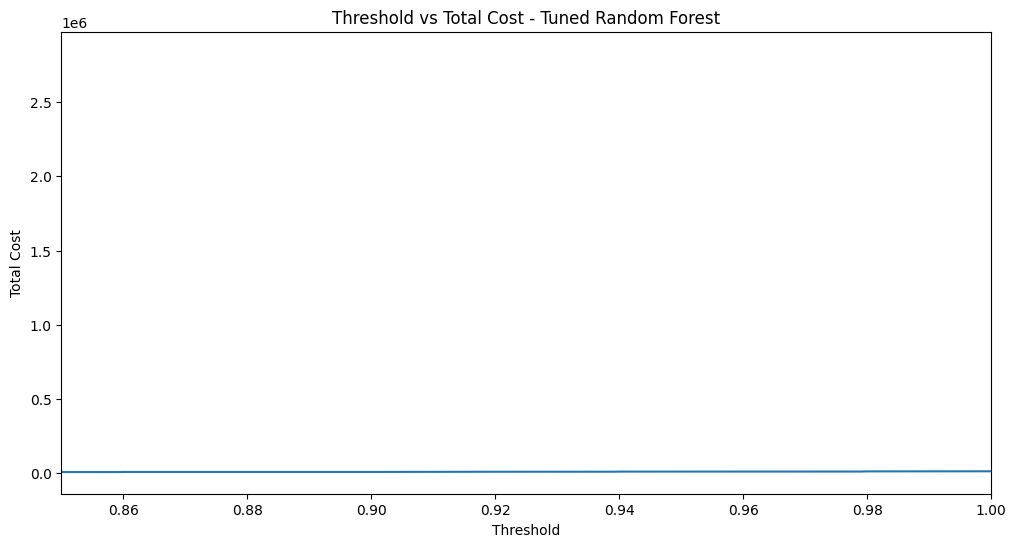

In [131]:
plot_threshold_cost(best_rf_results["thresholds"], tuned_costs, "Tuned Random Forest")
plot_threshold_cost(best_rf_results["thresholds"], tuned_costs, "Tuned Random Forest", xlim=(0.85, 1.0))

In [132]:
rf_threshold, rf_cost, rf_recall = choose_threshold(
    best_rf_results["thresholds"],
    best_rf_results["recall"],
    tuned_costs,
    recall_floor=0.75,
    threshold_cap=0.95
)

print("RF chosen threshold:", rf_threshold, "| recall:", rf_recall, "| cost:", rf_cost)

RF chosen threshold: 0.35916192636669947 | recall: 0.7789473684210526 | cost: 4190.34


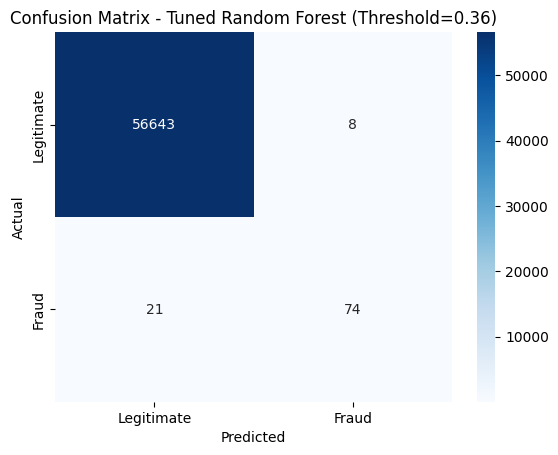

In [133]:
y_pred_on_chosen_threshold_rf = (best_rf_results["probabilities"] >= rf_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_on_chosen_threshold_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Confusion Matrix - Tuned Random Forest (Threshold={rf_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [134]:
rf_precision = precision_score(y_test, y_pred_on_chosen_threshold_rf)
rf_recall = recall_score(y_test, y_pred_on_chosen_threshold_rf)
rf_accuracy = accuracy_score(y_test, y_pred_on_chosen_threshold_rf)
rf_f1 = f1_score(y_test, y_pred_on_chosen_threshold_rf)

print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"F1 Score: {rf_f1:.4f}")

Precision: 0.9024
Recall: 0.7789
Accuracy: 0.9995
F1 Score: 0.8362


In [135]:
results = pd.DataFrame([
    {
        "Model": lr_results["model"],
        "Accuracy": lr_results["accuracy"],
        "Precision": lr_results["precision_score"],
        "Recall": lr_results["recall_score"],
        "F1": lr_results["f1_score"]
    },
    {
        "Model": nb_results["model"],
        "Accuracy": nb_results["accuracy"],
        "Precision": nb_results["precision_score"],
        "Recall": nb_results["recall_score"],
        "F1": nb_results["f1_score"]
    },
    {
        "Model": rf_results["model"],
        "Accuracy": rf_results["accuracy"],
        "Precision": rf_results["precision_score"],
        "Recall": rf_results["recall_score"],
        "F1": rf_results["f1_score"]
    },
    {
        "Model": best_rf_results["model"],
        "Accuracy": best_rf_results["accuracy"],
        "Precision": best_rf_results["precision_score"],
        "Recall": best_rf_results["recall_score"],
        "F1": best_rf_results["f1_score"]
    }
])

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.974853,0.055407,0.873684,0.104206
1,Naive Bayes,0.977426,0.057463,0.810526,0.107317
2,Random Forest,0.999471,0.971014,0.705263,0.817073
3,Tuned Random Forest,0.999471,0.933333,0.736842,0.823529


## Final model: Random Forest (tuned)

Compared against Logistic Regression at each model's own cost-optimal
threshold:

| | LogReg | Random Forest |
|---|---|---|
| Threshold | 0.9478 | 0.359 |
| Precision | 0.430 | 0.902 |
| Recall | 0.810 | 0.779 |
| F1 | 0.562 | 0.836 |
| Total cost | ₹8158 | ₹4190 |

Random Forest is selected as the final model — better precision, F1, and
roughly half the total cost, trading a small amount of recall. Naive Bayes
was tested and excluded (see earlier note — probability outputs cluster
near 0/1, limiting threshold tuning).

# SHAP Explainability

Use SHAP to explain why the selected Random Forest classified a transaction
as legitimate or fraudulent.

In [136]:
import shap

In [137]:
fitted_preprocessing = best_model.named_steps["preprocessor"]
rf_model = best_model.named_steps["model"]

In [138]:
def get_transformed_feature_names(fitted_preprocessor):
    """
    Extract feature names in the exact order produced by
    the fitted ColumnTransformer.
    """

    feature_names = []

    for name, transformer, columns in fitted_preprocessor.transformers_:

        if transformer == "drop":
            continue

        # Convert selected columns to a simple list
        columns = list(columns)

        # Try to get names from the fitted transformer
        if hasattr(transformer, "get_feature_names_out"):
            try:
                names = transformer.get_feature_names_out(columns)
            except AttributeError:
                names = np.asarray(columns, dtype=object)
        else:
            names = np.asarray(columns, dtype=object)

        # Match ColumnTransformer's default naming convention
        names = [
            f"{name}__{feature}"
            for feature in names
        ]

        feature_names.extend(names)

    return np.asarray(feature_names, dtype=object)

In [139]:
fitted_preprocessing = best_model.named_steps["preprocessor"]

feature_names = get_transformed_feature_names(
    fitted_preprocessing
)

print("Number of transformed features:", len(feature_names))
print(feature_names)

Number of transformed features: 30
['num__Time' 'num__V1' 'num__V2' 'num__V3' 'num__V4' 'num__V5' 'num__V6'
 'num__V7' 'num__V8' 'num__V9' 'num__V10' 'num__V11' 'num__V12' 'num__V13'
 'num__V14' 'num__V15' 'num__V16' 'num__V17' 'num__V18' 'num__V19'
 'num__V20' 'num__V21' 'num__V22' 'num__V23' 'num__V24' 'num__V25'
 'num__V26' 'num__V27' 'num__V28' 'amount__Amount']


In [140]:
def prepare_shap_data(model, X):
    """
    Transform raw data using the fitted preprocessor
    and return a DataFrame with correct feature names.
    """

    preprocessor = model.named_steps["preprocessor"]

    X_transformed = preprocessor.transform(X)

    feature_names = get_transformed_feature_names(
        preprocessor
    )

    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X.index
    )

    return X_transformed_df, feature_names

In [141]:
X_test_shap, feature_names = prepare_shap_data(
    best_model,
    X_test
)

In [142]:
def create_shap_explainer(model):
    """
    Create a TreeExplainer for the tree-based model
    inside the sklearn pipeline.
    """

    rf_model = model.named_steps["model"]

    explainer = shap.TreeExplainer(rf_model)

    return explainer

In [143]:
explainer = create_shap_explainer(best_model)

In [144]:
def calculate_shap_values(explainer, X_transformed):
    """
    Calculate SHAP values for the fraud class.
    """

    shap_values = explainer.shap_values(
        X_transformed
    )

    # Older SHAP versions return a list:
    # [class_0_values, class_1_values]
    if isinstance(shap_values, list):
        return shap_values[1]

    # Newer versions may return an array
    # with the class dimension included.
    if shap_values.ndim == 3:
        return shap_values[:, :, 1]

    return shap_values

In [145]:
shap_values_fraud = calculate_shap_values(
    explainer,
    X_test_shap
)

print(shap_values_fraud.shape)

(56746, 30)


In [146]:
def explain_transaction(
    model,
    explainer,
    X_transaction,
    threshold=0.359
):
    """
    Generate prediction and SHAP explanation
    for one raw transaction.
    """

    # Prediction
    probability = model.predict_proba(
        X_transaction
    )[0, 1]

    prediction = int(
        probability >= threshold
    )

    # Transform for SHAP
    X_transformed, feature_names = prepare_shap_data(
        model,
        X_transaction
    )

    # SHAP values
    shap_values = calculate_shap_values(
        explainer,
        X_transformed
    )

    return {
        "probability": probability,
        "prediction": prediction,
        "shap_values": shap_values[0],
        "feature_names": feature_names,
        "transformed_data": X_transformed.iloc[0]
    }

## Individual Transaction Explanations

Global SHAP analysis shows which features are generally important to the
model. The following examples demonstrate how SHAP can instead explain an
individual prediction.

Two real transactions from the held-out test set are used:
- a legitimate transaction
- a fraudulent transaction

This demonstrates both sides of the fraud-detection workflow.

In [147]:
transaction_explanation = explain_transaction(
    best_model,
    explainer,
    X_test.iloc[[0]],
    threshold=0.359
)

In [148]:
print(
    "Fraud probability:",
    transaction_explanation["probability"]
)

print(
    "Prediction:",
    "Fraud"
    if transaction_explanation["prediction"] == 1
    else "Legitimate"
)

Fraud probability: 0.0
Prediction: Legitimate


In [149]:
base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

reconstructed = (
    base_value +
    transaction_explanation["shap_values"].sum()
)

print("Reconstructed:", reconstructed)
print("Actual probability:", transaction_explanation["probability"])

Reconstructed: -3.4416913763379853e-13
Actual probability: 0.0


In [150]:
def plot_transaction_explanation(
    explanation,
    explainer,
    max_display=15
):

    base_value = explainer.expected_value

    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[1]

    shap_explanation = shap.Explanation(
        values=explanation["shap_values"],
        base_values=base_value,
        data=explanation["transformed_data"].values,
        feature_names=explanation["feature_names"]
    )

    shap.plots.waterfall(
        shap_explanation,
        max_display=max_display
    )

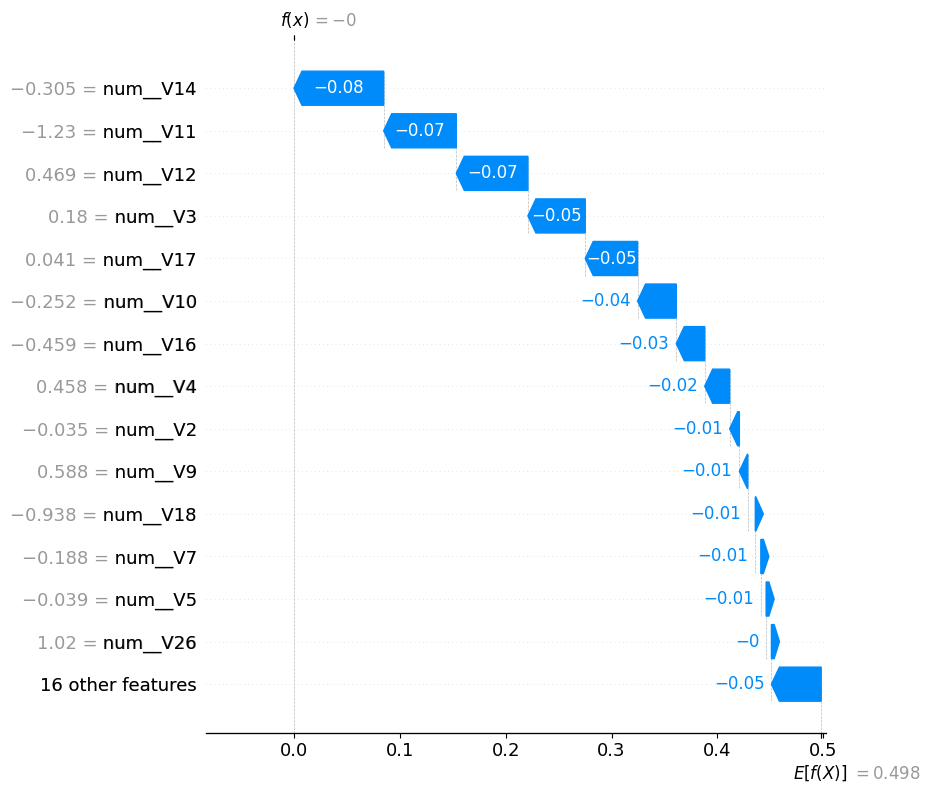

In [151]:
plot_transaction_explanation(
    transaction_explanation,
    explainer
)

Baseline reflects the class-weight-adjusted decision function, not the raw fraud prior — a consequence of class_weight='balanced'.

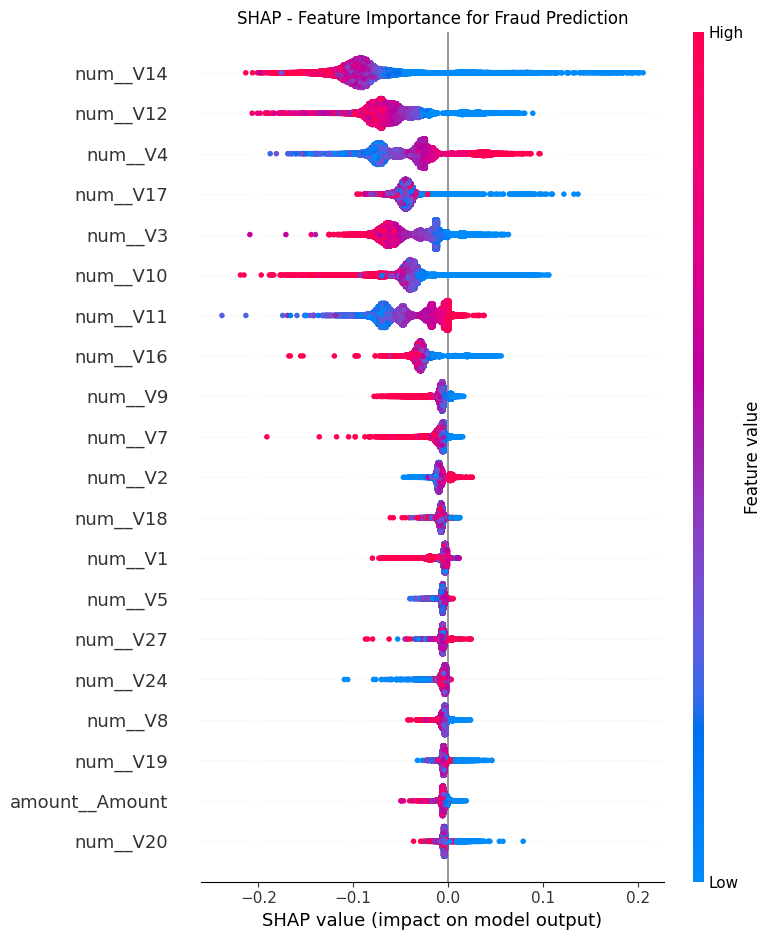

In [152]:
shap.summary_plot(shap_values_fraud, X_test_shap, feature_names=feature_names, show=False)
plt.title('SHAP - Feature Importance for Fraud Prediction')
plt.tight_layout()
plt.show()

In [153]:
print("Actual label:", y_test.iloc[0])

Actual label: 0


In [161]:
legitimate_transaction_explanation = explain_transaction(
    best_model,
    explainer,
    X_test.iloc[[0]],
    threshold=0.359
)

In [162]:
print("Transaction index:", 0)
print("Actual label: Legitimate")

print(
    "Legitimate probability:",
    legitimate_transaction_explanation["probability"]
)

print(
    "Prediction:",
    "Fraud"
    if legitimate_transaction_explanation["prediction"] == 1
    else "Legitimate"
)

Transaction index: 0
Actual label: Legitimate
Legitimate probability: 0.0
Prediction: Legitimate


## Example: Fraudulent Transaction Explanation

The following example selects a transaction that is actually fraudulent
according to the test-set ground truth and explains the model's prediction
using SHAP.

In [158]:
fraud_index = y_test[y_test == 1].index[0]

fraud_transaction_explanation = explain_transaction(
    best_model,
    explainer,
    X_test.loc[[fraud_index]],
    threshold=0.359
)

In [159]:
print("Transaction index:", fraud_index)
print("Actual label: Fraud")

print(
    "Fraud probability:",
    fraud_transaction_explanation["probability"]
)

print(
    "Prediction:",
    "Fraud"
    if fraud_transaction_explanation["prediction"] == 1
    else "Legitimate"
)

Transaction index: 115676
Actual label: Fraud
Fraud probability: 0.9594211814139884
Prediction: Fraud


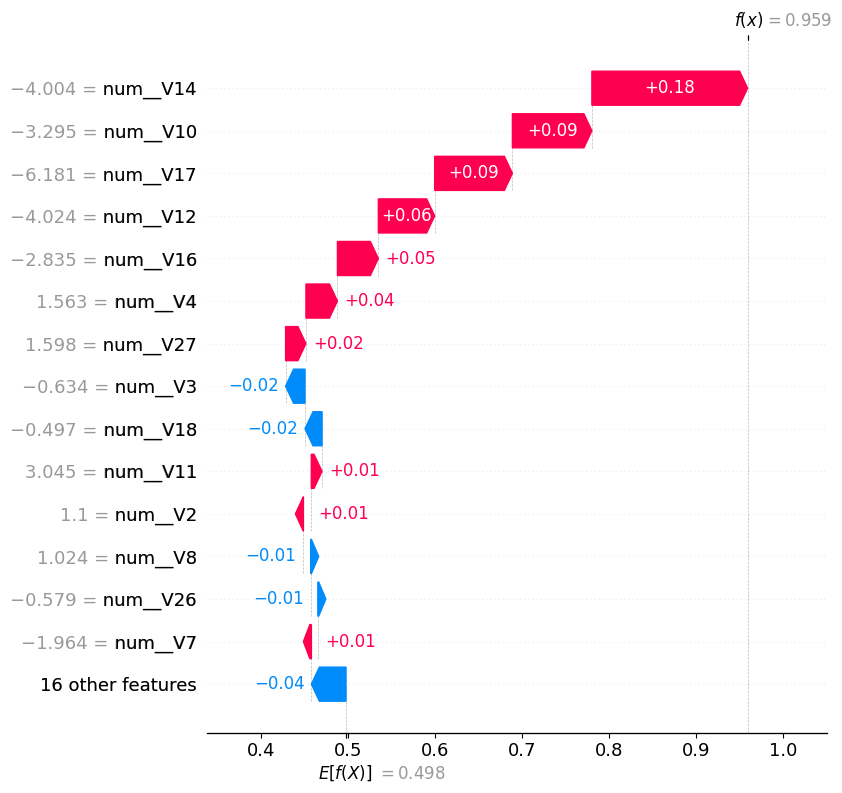

In [160]:
plot_transaction_explanation(
    fraud_transaction_explanation,
    explainer
)

In [155]:
fitted_preprocessing, feature_names, X_test_shap, explainer = (
    prepare_shap_artifacts(
        best_model,
        X_test
    )
)

In [156]:
# Complete model pipeline
joblib.dump(
    best_model,
    os.path.join(MODEL_DIR, "model.pkl")
)

# Correct transformed feature names
joblib.dump(
    feature_names.tolist(),
    os.path.join(MODEL_DIR, "feature_names.pkl")
)

# SHAP explainer
joblib.dump(
    explainer,
    os.path.join(MODEL_DIR, "shap_explainer.pkl")
)

print("All model artifacts saved successfully.")

All model artifacts saved successfully.


In [157]:
for filename in [
    "model.pkl",
    "feature_names.pkl",
    "shap_explainer.pkl"
]:
    path = os.path.join(MODEL_DIR, filename)

    print(
        filename,
        "✓" if os.path.exists(path) else "✗"
    )

model.pkl ✓
feature_names.pkl ✓
shap_explainer.pkl ✓


## Final Model Artifacts

The following artifacts are saved for deployment:

| Artifact | Purpose |
|---|---|
| `model.pkl` | Complete trained Random Forest pipeline, including preprocessing and the final classifier |
| `feature_names.pkl` | Names of the 30 transformed features used by the Random Forest and SHAP |
| `shap_explainer.pkl` | Pre-built SHAP TreeExplainer used to explain individual predictions |

The preprocessing pipeline is not saved separately because it is already
contained inside `model.pkl`.

The production classification threshold is **0.359**, selected during model
evaluation based on the precision, recall, and business-cost trade-off.